# 6 · Adaptive cruise control from confounded fleet logs (a relatable end-to-end)

A concrete, everyday control problem that ties the whole library together. We want **adaptive cruise
control**: hold the car at a target speed by setting the throttle. We only have **observational fleet
logs** — no controlled experiment — and they are confounded:

> On hills, drivers pressed the throttle *harder*, yet the car went *slower* (the grade fought them).
> So in the raw logs, **more throttle correlates with lower speed** — as if the throttle were a brake.

A predictive model trained on those logs learns exactly that wrong lesson. Deployed as a cruise
controller, it *brakes to speed up* and the car stalls. `chc` recovers the true throttle→speed effect
(by adjusting for grade, or — if grade is unmeasured — from a randomised throttle nudge via IV) and the
controller holds speed. Same machinery as the pricing flagship, in a domain everyone has felt.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

jax.config.update("jax_enable_x64", True)
%matplotlib inline

from chc.causal import (
    ConfoundedLinearSystem,
    estimate_control_effect,
    estimate_effect_iv,
    sensitivity_analysis,
)
from chc.flagship import closed_loop

# x = speed (relative to base), u = throttle, z = road grade (the confounder), w = randomised nudge.
# True effect of throttle on next speed is +1.0; grade slows the car (c<0) and drivers gave more
# throttle on steeper grade (kappa>0) — so the naive throttle->speed estimate flips negative.
cruise = ConfoundedLinearSystem(a=0.5, b_true=1.0, c=-2.0, kappa=1.5, gamma=0.0)
logs = cruise.sample(20_000, jax.random.key(0))

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


## The logs look like "throttle slows the car"

Colour each logged step by road grade. Steep-grade points (dark) cluster at **high throttle but low
resulting speed**; the pooled trend line slopes *down*. Within any single grade band the true
relationship is positive — this is Simpson's paradox, and it is a confounded control effect.

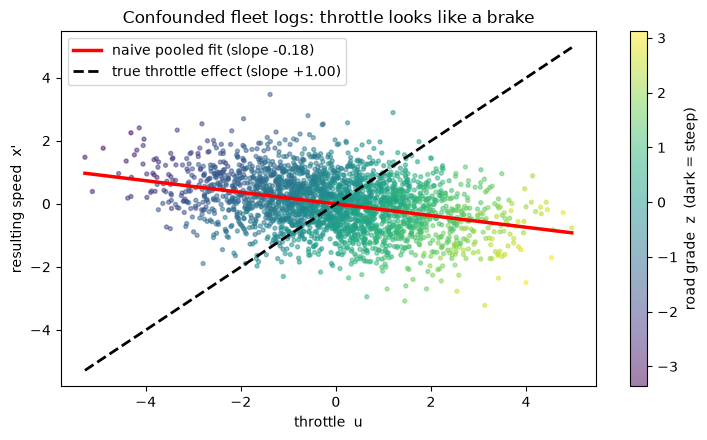

In [2]:
idx = jax.random.choice(jax.random.key(1), logs["u"].shape[0], (2500,), replace=False)
u_s, y_s, z_s = np.asarray(logs["u"][idx]), np.asarray(logs["x_next"][idx]), np.asarray(logs["z"][idx])
slope, intercept = np.polyfit(u_s, y_s, 1)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
sc = ax.scatter(u_s, y_s, c=z_s, cmap="viridis", s=8, alpha=0.5)
xs_line = np.linspace(u_s.min(), u_s.max(), 2)
ax.plot(xs_line, slope * xs_line + intercept, "r-", lw=2.5, label=f"naive pooled fit (slope {slope:+.2f})")
ax.plot(xs_line, 1.0 * xs_line + intercept, "k--", lw=2, label="true throttle effect (slope +1.00)")
ax.set_xlabel("throttle  u")
ax.set_ylabel("resulting speed  x'")
ax.set_title("Confounded fleet logs: throttle looks like a brake")
plt.colorbar(sc, label="road grade  z  (dark = steep)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## Estimate the throttle→speed effect four ways

- **naive** (regress speed on throttle) — confounded, wrong sign;
- **adjust for grade** — if the grade is logged, conditioning on it blocks the backdoor;
- **IV** — if grade is *not* logged but a subset of the fleet got a **randomised throttle nudge**
  (instrument `w`), 2SLS recovers the effect;
- each with a **robustness value** (how much hidden confounding the estimate tolerates).

In [3]:
ab_logs = ConfoundedLinearSystem(a=0.5, b_true=1.0, c=-2.0, kappa=1.5, gamma=1.0).sample(
    40_000, jax.random.key(2)
)  # a fleet with a randomised throttle nudge active
estimates = pd.DataFrame(
    {
        "estimate": [
            1.0,
            float(estimate_control_effect(logs, adjust_for=())),
            float(estimate_control_effect(logs, adjust_for=("z",))),
            float(estimate_effect_iv(ab_logs, instrument="w")),
        ],
        "robustness value": [
            np.nan,
            sensitivity_analysis(logs, adjust_for=())["robustness_value"],
            sensitivity_analysis(logs, adjust_for=("z",))["robustness_value"],
            np.nan,
        ],
    },
    index=["true effect", "naive", "adjust for grade (causal)", "IV (randomised nudge)"],
).round(3)
estimates

,estimate,robustness value
true effect,1.000,NaN
naive,-0.203,0.395
adjust for grade (causal),0.999,0.963
IV (randomised nudge),0.994,NaN


The naive estimate is **negative** (throttle "slows" the car) and **fragile** (near-zero robustness
value); adjusting for grade and IV both recover ≈ **+1.0**, robustly.

## Deploy as cruise control: hold +2 above base speed

Plan with each estimate, act on the true car (`chc`'s model/plant split). The causal controller opens
the throttle and holds the setpoint; the predictive controller — believing throttle is a brake — lifts
off / brakes to "gain" speed and the car falls away.

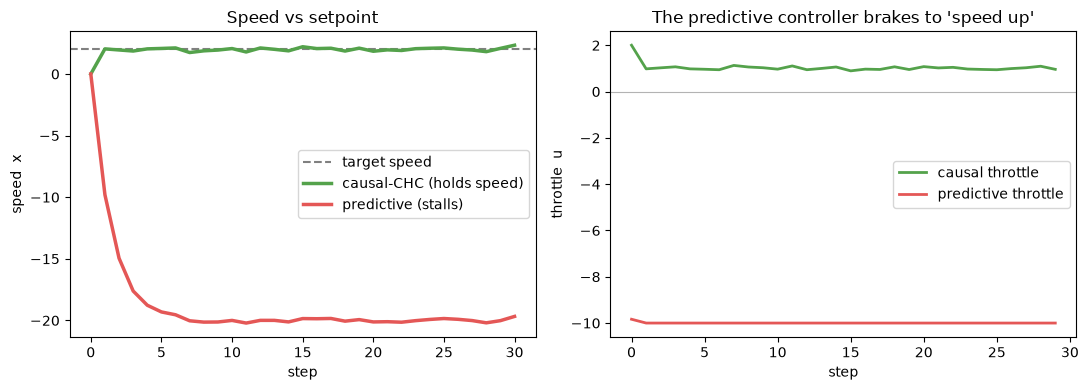

final speed  — causal: +2.33   predictive: -19.68   (target 2.0)


In [4]:
x0, target, n_steps = jnp.asarray(0.0), 2.0, 30
key = jax.random.key(7)
b_naive = float(estimate_control_effect(logs, adjust_for=()))
b_causal = float(estimate_control_effect(logs, adjust_for=("z",)))
xs_causal, us_causal = closed_loop(cruise, b_causal, x0, target, n_steps, -10.0, 10.0, key)
xs_naive, us_naive = closed_loop(cruise, b_naive, x0, target, n_steps, -10.0, 10.0, key)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.axhline(target, ls="--", c="0.5", label="target speed")
ax1.plot(xs_causal, lw=2.5, color="#54A24B", label="causal-CHC (holds speed)")
ax1.plot(xs_naive, lw=2.5, color="#E45756", label="predictive (stalls)")
ax1.set_xlabel("step")
ax1.set_ylabel("speed  x")
ax1.set_title("Speed vs setpoint")
ax1.legend()
ax2.plot(us_causal, lw=2, color="#54A24B", label="causal throttle")
ax2.plot(us_naive, lw=2, color="#E45756", label="predictive throttle")
ax2.axhline(0, c="0.7", lw=0.8)
ax2.set_xlabel("step")
ax2.set_ylabel("throttle  u")
ax2.set_title("The predictive controller brakes to 'speed up'")
ax2.legend()
plt.tight_layout()
plt.show()

print(f"final speed  — causal: {float(xs_causal[-1]):+.2f}   predictive: {float(xs_naive[-1]):+.2f}   (target {target})")

### Takeaway
Same failure and same fix as the pricing flagship, in a domain you can feel: **prediction learns the
confounded association, control needs the intervention.** Adjust for the confounder when you can measure
it, reach for an instrument when you cannot — then let optimal control do its job on the true system.